# 01 Data Overview

First-pass EDA for `DATA/data_sample_1000/sample_data.parquet`. This notebook inspects top-level columns, nested feature structures, label distribution, and timestamp coverage. It also saves summary artifacts to `OUTPUTS/01_eda`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

project_root = Path.cwd().resolve().parents[1]
data_path = project_root / "DATA" / "data_sample_1000" / "sample_data.parquet"
output_dir = project_root / "OUTPUTS" / "01_eda"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data path: {data_path}")
print(f"Output dir: {output_dir}")

Project root: D:\ProjectManage\KDDTAAC
Data path: D:\ProjectManage\KDDTAAC\DATA\data_sample_1000\sample_data.parquet
Output dir: D:\ProjectManage\KDDTAAC\OUTPUTS\01_eda


In [2]:
table = pq.read_table(data_path)
df = table.to_pandas()

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head(3)

Shape: (1000, 7)
Columns: ['item_id', 'item_feature', 'label', 'seq_feature', 'timestamp', 'user_feature', 'user_id']


,item_id,item_feature,label,seq_feature,timestamp,user_feature,user_id
0,1548,"[{'feature_id': 6, 'feature_value_type': 'int_...","[{'action_time': 1770565361, 'action_type': 1}]","{'action_seq': [{'feature_id': 19, 'feature_va...",1770565208,"[{'feature_id': 65, 'feature_value_type': 'int...",user_3059
1,2537,"[{'feature_id': 6, 'feature_value_type': 'int_...","[{'action_time': 1770692680, 'action_type': 1}]","{'action_seq': [{'feature_id': 19, 'feature_va...",1770691713,"[{'feature_id': 58, 'feature_value_type': 'int...",user_3646
2,3244,"[{'feature_id': 6, 'feature_value_type': 'int_...","[{'action_time': 1770698500, 'action_type': 1}]","{'action_seq': [{'feature_id': 19, 'feature_va...",1770698286,"[{'feature_id': 55, 'feature_value_type': 'int...",user_2282


In [3]:
schema_text = table.schema.to_string(show_field_metadata=False)
print(schema_text)
(output_dir / "pyarrow_schema.txt").write_text(schema_text, encoding="utf-8")

item_id: int64
item_feature: list<element: struct<feature_id: int64, feature_value_type: string, float_value: null, int_array: li (... 39 chars omitted)
  child 0, element: struct<feature_id: int64, feature_value_type: string, float_value: null, int_array: list<element: in (... 24 chars omitted)
      child 0, feature_id: int64
      child 1, feature_value_type: string
      child 2, float_value: null
      child 3, int_array: list<element: int64>
          child 0, element: int64
      child 4, int_value: double
label: list<element: struct<action_time: int64, action_type: int64>>
  child 0, element: struct<action_time: int64, action_type: int64>
      child 0, action_time: int64
      child 1, action_type: int64
seq_feature: struct<action_seq: list<element: struct<feature_id: int64, feature_value_type: string, int_array: li (... 250 chars omitted)
  child 0, action_seq: list<element: struct<feature_id: int64, feature_value_type: string, int_array: list<element: int64>> (... 1 chars om

2838

In [4]:
column_summary = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [str(dtype) for dtype in df.dtypes],
    "null_count": [int(df[col].isna().sum()) for col in df.columns],
    "non_null_count": [int(df[col].notna().sum()) for col in df.columns],
    "sample_python_type": [type(df[col].iloc[0]).__name__ for col in df.columns],
})
column_summary.to_csv(output_dir / "column_summary.csv", index=False)
column_summary

,column,pandas_dtype,null_count,non_null_count,sample_python_type
0,item_id,int64,0,1000,int64
1,item_feature,object,0,1000,ndarray
2,label,object,0,1000,ndarray
3,seq_feature,object,0,1000,dict
4,timestamp,int64,0,1000,int64
5,user_feature,object,0,1000,ndarray
6,user_id,str,0,1000,str


In [5]:
def safe_len(value):
    if value is None:
        return 0
    try:
        return len(value)
    except TypeError:
        return 0

length_df = pd.DataFrame({
    "user_feature_len": df["user_feature"].map(safe_len),
    "item_feature_len": df["item_feature"].map(safe_len),
    "label_len": df["label"].map(safe_len),
    "seq_action_seq_len": df["seq_feature"].map(lambda x: safe_len(x.get("action_seq")) if isinstance(x, dict) else 0),
    "seq_content_seq_len": df["seq_feature"].map(lambda x: safe_len(x.get("content_seq")) if isinstance(x, dict) else 0),
    "seq_item_seq_len": df["seq_feature"].map(lambda x: safe_len(x.get("item_seq")) if isinstance(x, dict) else 0),
})
length_summary = length_df.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
length_summary.to_csv(output_dir / "nested_length_summary.csv")
length_summary

,count,mean,std,min,25%,50%,75%,max
user_feature_len,1000.0,38.662,5.873862,13.0,35.0,39.0,43.0,54.0
item_feature_len,1000.0,11.860,1.096176,11.0,11.0,12.0,12.0,15.0
label_len,1000.0,1.000,0.000000,1.0,1.0,1.0,1.0,1.0
seq_action_seq_len,1000.0,9.980,0.446990,0.0,10.0,10.0,10.0,10.0
seq_content_seq_len,1000.0,9.000,0.000000,9.0,9.0,9.0,9.0,9.0
seq_item_seq_len,1000.0,12.000,0.000000,12.0,12.0,12.0,12.0,12.0


In [6]:
label_records = []
for labels in df["label"]:
    if not labels:
        continue
    for entry in labels:
        if isinstance(entry, dict):
            label_records.append(entry)

label_df = pd.DataFrame(label_records)
action_type_counts = (
    label_df["action_type"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("action_type")
    .reset_index(name="count")
)
action_type_counts.to_csv(output_dir / "label_action_type_counts.csv", index=False)
action_type_counts

,action_type,count
0,1,897
1,2,103


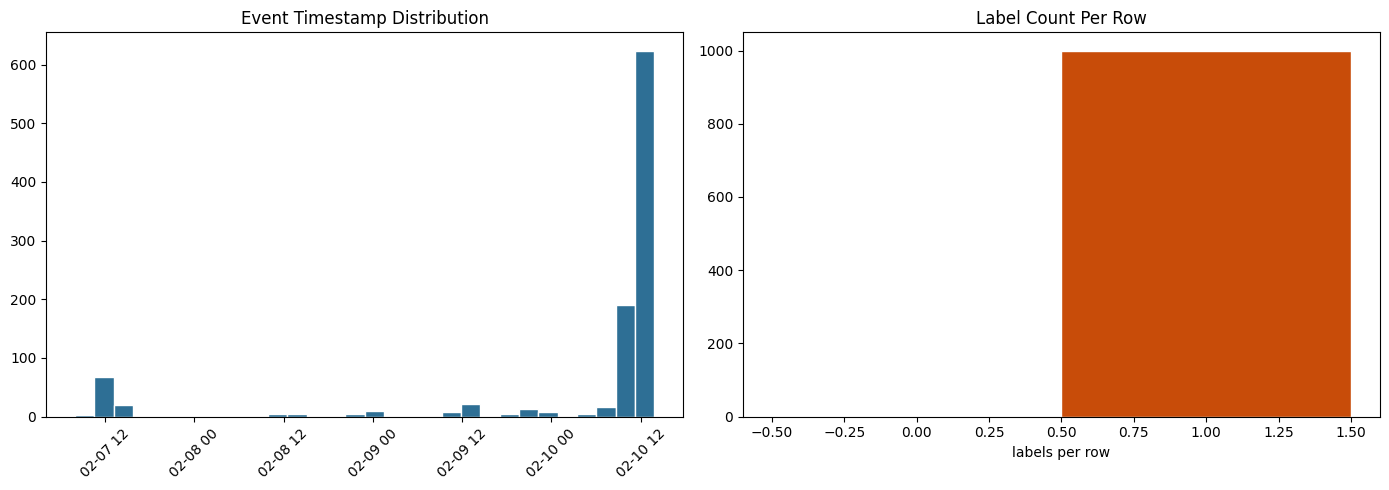

In [7]:
timestamp_series = pd.to_datetime(df["timestamp"], unit="s", utc=True).dt.tz_convert("Asia/Shanghai")
row_label_counts = df["label"].map(safe_len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(timestamp_series, bins=30, color="#2E6F95", edgecolor="white")
axes[0].set_title("Event Timestamp Distribution")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(row_label_counts, bins=range(int(row_label_counts.max()) + 2), align="left", color="#C84C09", edgecolor="white")
axes[1].set_title("Label Count Per Row")
axes[1].set_xlabel("labels per row")

plt.tight_layout()
fig.savefig(output_dir / "overview_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
summary_lines = [
    "# Data Overview Summary",
    "",
    f"- Rows: {df.shape[0]}",
    f"- Columns: {df.shape[1]}",
    f"- Unique users: {df['user_id'].nunique()}",
    f"- Unique items: {df['item_id'].nunique()}",
    f"- Timestamp min (Asia/Shanghai): {timestamp_series.min()}",
    f"- Timestamp max (Asia/Shanghai): {timestamp_series.max()}",
    f"- Mean user_feature length: {length_df['user_feature_len'].mean():.2f}",
    f"- Mean item_feature length: {length_df['item_feature_len'].mean():.2f}",
    f"- Mean label count per row: {length_df['label_len'].mean():.2f}",
    f"- Mean action sequence length: {length_df['seq_action_seq_len'].mean():.2f}",
    "",
    "## Action Type Counts",
]
summary_lines.extend([f"- action_type={row.action_type}: {row.count}" for row in action_type_counts.itertuples(index=False)])
summary_text = "\n".join(summary_lines)
(output_dir / "data_overview_summary.md").write_text(summary_text, encoding="utf-8")
print(summary_text)

# Data Overview Summary

- Rows: 1000
- Columns: 7
- Unique users: 1000
- Unique items: 927
- Timestamp min (Asia/Shanghai): 2026-02-07 07:59:10+08:00
- Timestamp max (Asia/Shanghai): 2026-02-10 13:48:31+08:00
- Mean user_feature length: 38.66
- Mean item_feature length: 11.86
- Mean label count per row: 1.00
- Mean action sequence length: 9.98

## Action Type Counts
- action_type=1: 897
- action_type=2: 103
